# SARSA Agent Training Notebook

This notebook trains a **SARSA** (model-free, on-policy) reinforcement learning agent on a randomly selected Micromouse maze.

SARSA learns only from physically executed actions, making it more conservative during exploration.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.dpi'] = 100

from mazemind.envs.maze_parser import parse_maze_file, list_maze_files, load_random_maze, ACTION_DELTAS
from mazemind.envs.micromouse_env import MicromouseEnv
from mazemind.agents.sarsa import SarsaAgent
from mazemind.training.orchestrator import train_with_snapshots, extract_optimal_path
from mazemind.visualization.maze_renderer import render_maze
from mazemind.visualization.heatmap import render_heatmap, render_q_value_map

print('All imports successful.')

All imports successful.


## 1. Load a Random Maze

Loaded maze: 87sin
Start: (0, 0), Goals: {(8, 7), (8, 8), (7, 7), (7, 8)}
Size: 16x16


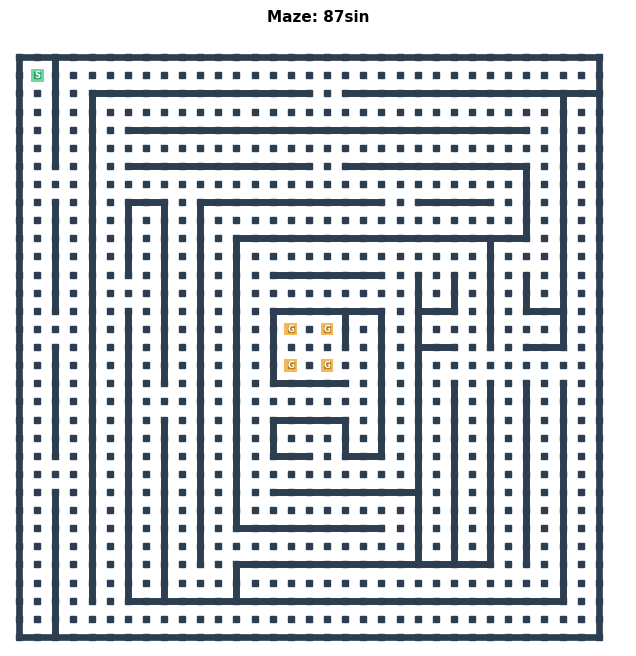

In [2]:
maze_dir = os.path.join('data', 'mazes', 'classic')

files = list_maze_files(maze_dir)
if len(files) < 3:
    from mazemind.envs.maze_parser import download_mazes
    download_mazes(maze_dir)
    files = list_maze_files(maze_dir)

maze = load_random_maze(maze_dir)
print(f'Loaded maze: {maze.name}')
print(f'Start: {maze.start}, Goals: {maze.goals}')
print(f'Size: {maze.size}x{maze.size}')

fig, ax = render_maze(maze, title=f'Maze: {maze.name}')
plt.show()

## 2. Configure and Train SARSA Agent

In [3]:
alpha = 0.1
gamma = 0.99
epsilon_start = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01
n_episodes = 500
max_steps = 1000
seed = 42

agent = SarsaAgent(
    epsilon=epsilon_start,
    epsilon_min=epsilon_min,
    epsilon_decay=epsilon_decay,
)
env = MicromouseEnv(maze)

metrics, snapshots, all_traj, exploration = train_with_snapshots(
    agent, env, n_episodes=n_episodes, max_steps=max_steps,
    alpha=alpha, gamma=gamma, seed=seed,
    snapshot_episodes=[0, 1, 5, 10, 25, 50, 100, 200, 499],
    agent_name='SARSA', maze_name=maze.name,
)

summary = metrics.summary()
for k, v in summary.items():
    print(f'{k}: {v}')

agent: SARSA
maze: 87sin
total_episodes: 500
mean_reward: -368.944
std_reward: 338.4529226701994
mean_steps: 453.582
total_successes: 419
success_rate: 0.838
episodes_to_convergence: 176
total_steps_to_convergence: 139310


## 3. Learning Curves

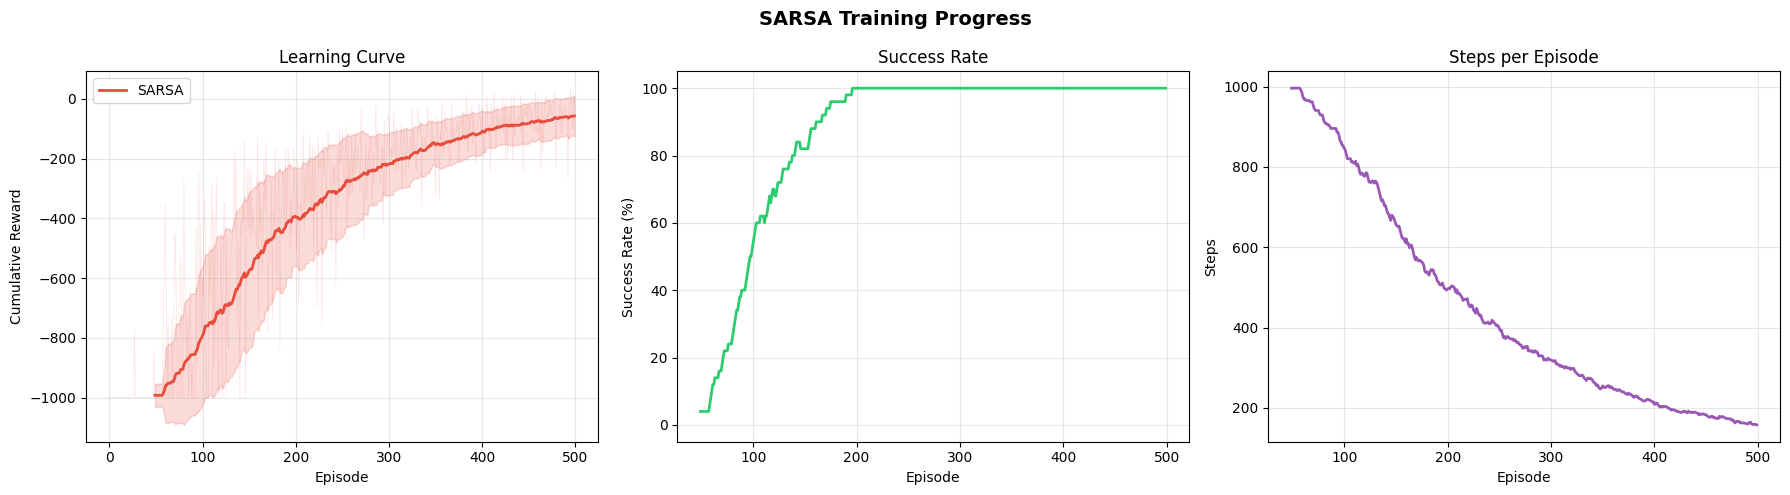

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

window = 50
episodes = np.arange(n_episodes)

# Reward curve
axes[0].plot(episodes, metrics.rewards, alpha=0.15, color='#e74c3c', linewidth=0.5)
smoothed = metrics.avg_reward(window)
axes[0].plot(episodes[window-1:], smoothed, color='#e74c3c', linewidth=2, label='SARSA')
std = np.array([metrics.rewards[max(0,i-window+1):i+1].std() for i in range(window-1, n_episodes)])
axes[0].fill_between(episodes[window-1:], smoothed - std, smoothed + std, alpha=0.2, color='#e74c3c')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Cumulative Reward')
axes[0].set_title('Learning Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Success rate
sr = metrics.success_rate(window)
axes[1].plot(episodes[window-1:], sr * 100, color='#2ecc71', linewidth=2)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Success Rate (%)')
axes[1].set_title('Success Rate')
axes[1].set_ylim(-5, 105)
axes[1].grid(True, alpha=0.3)

# Steps
steps_smooth = np.convolve(metrics.steps, np.ones(window)/window, mode='valid')
axes[2].plot(episodes[window-1:], steps_smooth, color='#9b59b6', linewidth=2)
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Steps')
axes[2].set_title('Steps per Episode')
axes[2].grid(True, alpha=0.3)

plt.suptitle('SARSA Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Optimal Path Discovery

Optimal path length: 3 steps
Path: [(0, 0), (1, 0), (1, 0)]...


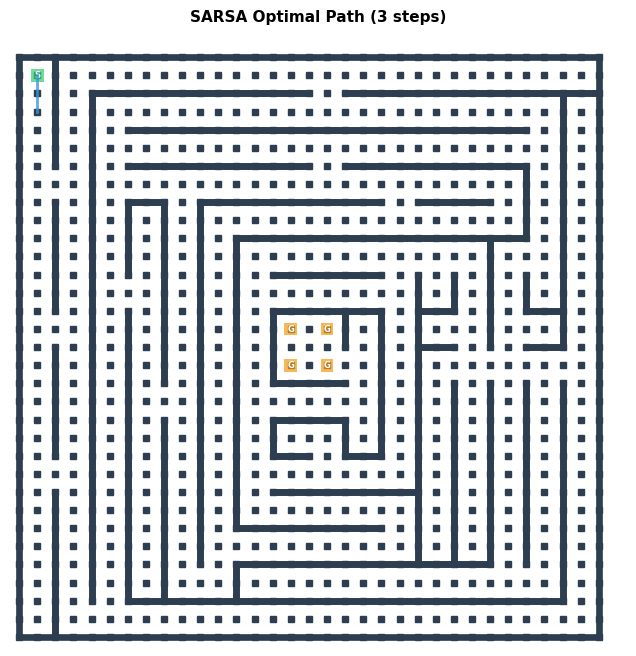

In [5]:
path = extract_optimal_path(agent, MicromouseEnv(maze))
print(f'Optimal path length: {len(path)} steps')
print(f'Path: {path[:10]}...')

fig, ax = render_maze(maze, title=f'SARSA Optimal Path ({len(path)} steps)', path=path)
plt.show()

## 5. State Visitation Heatmap

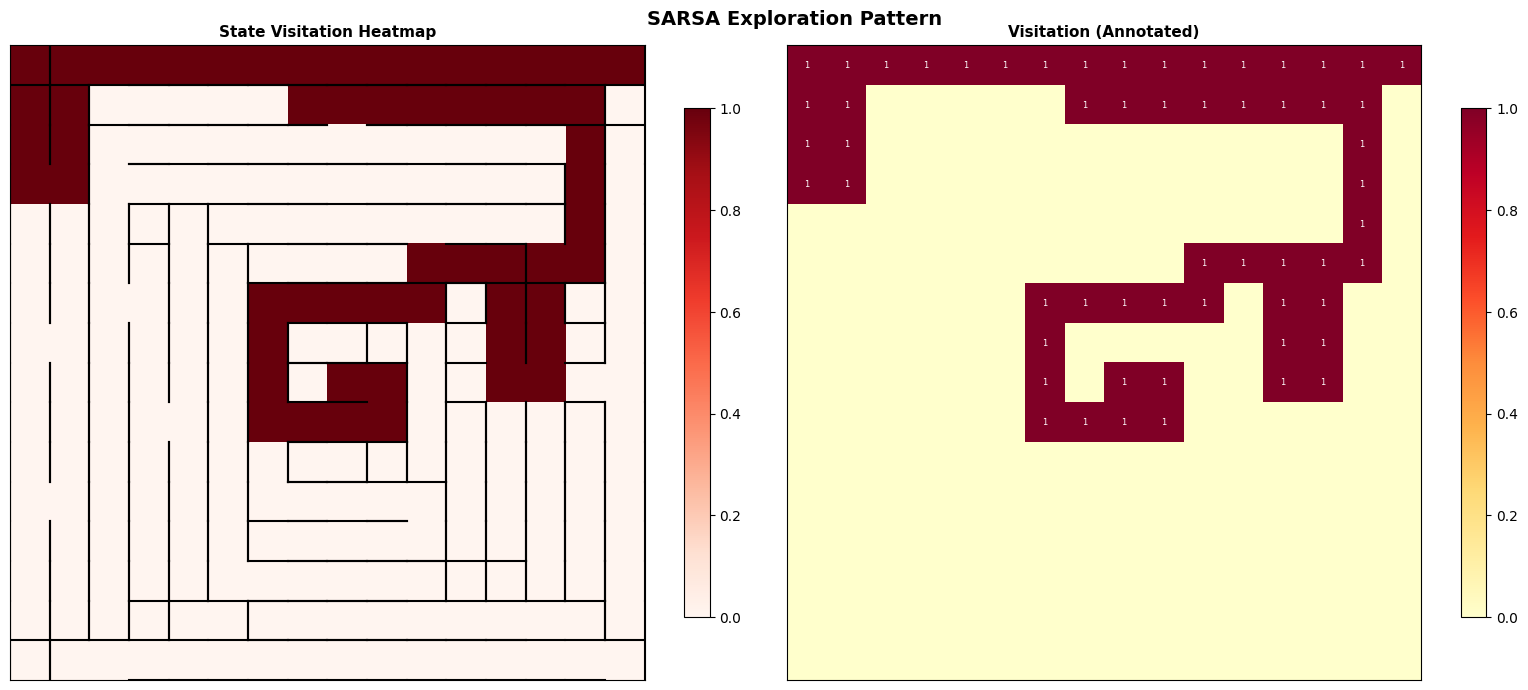

In [6]:
visit_counts = env.get_visit_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

render_heatmap(visit_counts, ax=axes[0], title='State Visitation Heatmap', cmap='Reds', maze=maze)
render_heatmap(visit_counts, ax=axes[1], title='Visitation (Annotated)', cmap='YlOrRd', annotate=True)

plt.suptitle('SARSA Exploration Pattern', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Q-Value Visualization

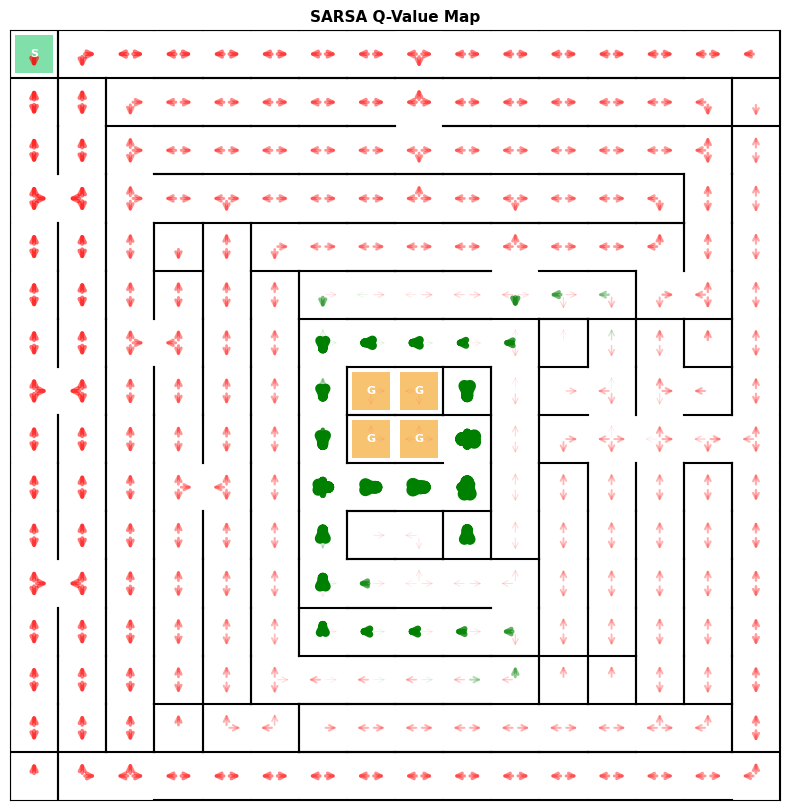

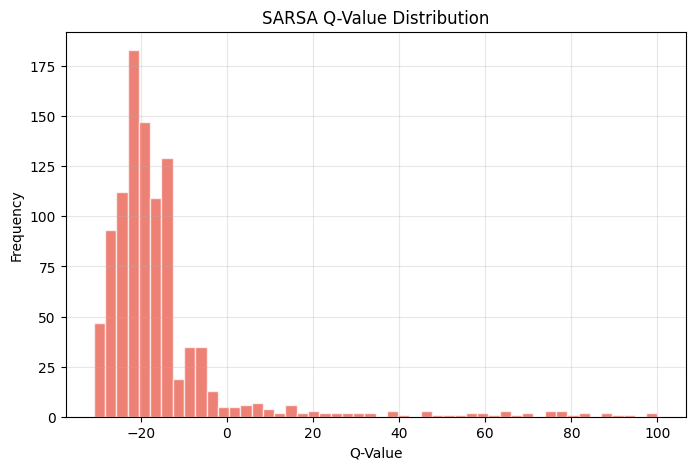

Q-table stats: min=-30.9315, max=100.0000, mean_nonzero=-14.7508


In [7]:
fig, ax = render_q_value_map(agent.q_table, maze, title='SARSA Q-Value Map')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
q_vals = agent.q_table[agent.q_table != 0].flatten()
if len(q_vals) > 0:
    ax.hist(q_vals, bins=50, color='#e74c3c', alpha=0.7, edgecolor='white')
ax.set_xlabel('Q-Value')
ax.set_ylabel('Frequency')
ax.set_title('SARSA Q-Value Distribution')
ax.grid(True, alpha=0.3)
plt.show()

print(f'Q-table stats: min={agent.q_table.min():.4f}, max={agent.q_table.max():.4f}, '
      f'mean_nonzero={q_vals.mean() if len(q_vals)>0 else 0:.4f}')

## 7. Dynamic Visualization: Episode Replay

In [8]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

if len(path) > 1:
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    def animate(frame):
        ax.clear()
        render_maze(maze, ax=ax, title=f'SARSA Path Replay (step {frame+1}/{len(path)})',
                   path=path[:frame+1], agent_pos=path[frame])

    anim = FuncAnimation(fig, animate, frames=len(path), interval=200, repeat=True)
    plt.close()
    display(HTML(anim.to_jshtml()))
else:
    print('Path too short for animation.')

In [9]:
# ## Training Process: Q-Table and Policy Evolution

from mazemind.visualization.training_viz import render_training_panel
from mazemind.visualization.maze_renderer import _cell_vertex
from matplotlib.collections import LineCollection

def _cell_center_viz(r, c):
    vr_top = 2 * (maze.size - 1 - r) + 1
    vc_left = 2 * c + 1
    U = 10
    return vc_left * U, vr_top * U

def _draw_walls(ax):
    n = maze.size
    U = 10
    h_segs, v_segs = [], []
    for r in range(n):
        for c in range(n):
            vr_top = 2 * (n - 1 - r)
            vr_bot = vr_top + 2
            vc_left = 2 * c
            vc_right = vc_left + 2
            if maze.walls[r][c]['N']:
                h_segs.append([(vc_left * U, vr_top * U), (vc_right * U, vr_top * U)])
            if maze.walls[r][c]['S']:
                h_segs.append([(vc_left * U, vr_bot * U), (vc_right * U, vr_bot * U)])
            if maze.walls[r][c]['W']:
                v_segs.append([(vc_left * U, vr_top * U), (vc_left * U, vr_bot * U)])
            if maze.walls[r][c]['E']:
                v_segs.append([(vc_right * U, vr_top * U), (vc_right * U, vr_bot * U)])
    if h_segs:
        ax.add_collection(LineCollection(h_segs, colors='#2c3e50', linewidths=1.5, capstyle='butt', zorder=3))
    if v_segs:
        ax.add_collection(LineCollection(v_segs, colors='#2c3e50', linewidths=1.5, capstyle='butt', zorder=3))
    ax.set_xlim(-5, (2 * n + 1) * U + 5)
    ax.set_ylim(-5, (2 * n + 1) * U + 5)
    ax.set_aspect('equal')
    ax.axis('off')

snap_eps = [s.episode for s in snapshots]
key_eps = [e for e in [1, 10, 50, min(200, n_episodes - 1), n_episodes - 1] if e in snap_eps]

fig, axes = plt.subplots(len(key_eps), 3, figsize=(15, 4 * len(key_eps)))
if len(key_eps) == 1:
    axes = [axes]

for i, ep in enumerate(key_eps):
    snap = next(s for s in snapshots if s.episode == ep)
    
    # Grid
    ax = axes[i][0]
    vmax = max(snap.visit_counts.max(), 1)
    for r in range(maze.size):
        for c in range(maze.size):
            if snap.visit_counts[r][c] > 0:
                cx, cy = _cell_center_viz(r, c)
                intensity = snap.visit_counts[r][c] / vmax
                color = plt.cm.YlOrRd(intensity)
                ax.add_patch(plt.Rectangle((cx-4, cy-4), 8, 8, facecolor=color, alpha=0.5, zorder=1))
    if len(snap.path) > 1:
        px = [_cell_center_viz(r,c)[0] for r,c in snap.path]
        py = [_cell_center_viz(r,c)[1] for r,c in snap.path]
        ax.plot(px, py, color='#3498db', linewidth=1, alpha=0.7, zorder=3)
    if snap.path:
        cx, cy = _cell_center_viz(*snap.path[-1])
        ax.add_patch(plt.Circle((cx, cy), 3, facecolor='#e74c3c', edgecolor='darkred', linewidth=0.8, zorder=5))
    _draw_walls(ax)
    ax.set_title(f'Ep {ep}: Grid', fontsize=9)
    
    # Q-Table
    ax = axes[i][1]
    max_q = np.array([np.max(snap.q_table_snapshot[r * maze.size + c]) for r in range(maze.size) for c in range(maze.size)]).reshape(maze.size, maze.size)
    vmax_q = max(abs(max_q.max()), abs(max_q.min()), 1e-6)
    for r in range(maze.size):
        for c in range(maze.size):
            cx, cy = _cell_center_viz(r, c)
            norm_val = (max_q[r][c] + vmax_q) / (2 * vmax_q)
            ax.add_patch(plt.Rectangle((cx-4, cy-4), 8, 8, facecolor=plt.cm.coolwarm(norm_val), alpha=0.8, edgecolor='none', zorder=1))
    _draw_walls(ax)
    ax.set_title(f'Ep {ep}: Q-Table', fontsize=9)
    
    # Policy
    ax = axes[i][2]
    for r in range(maze.size):
        for c in range(maze.size):
            si = r * maze.size + c
            cx, cy = _cell_center_viz(r, c)
            best_a = int(np.argmax(snap.q_table_snapshot[si]))
            best_q = snap.q_table_snapshot[si][best_a]
            dr, dc = ACTION_DELTAS[best_a]
            if abs(best_q) > 0.01:
                color = '#27ae60' if best_q > 0 else '#c0392b'
                alpha = min(abs(best_q) / 50.0, 1.0)
                alpha = max(alpha, 0.3)
                ax.annotate('', xy=(cx + dc*3, cy + dr*3), xytext=(cx - dc*3, cy - dr*3),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=alpha), zorder=2)
    _draw_walls(ax)
    ax.set_title(f'Ep {ep}: Policy', fontsize=9)

plt.suptitle('Training Process Evolution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


C:\Users\Bilal\AppData\Local\Temp\ipykernel_26316\1452278696.py:102: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
